In [ ]:
import route_network_analysis as rna
import osmnx as ox

ume = (63.827121,20.267437)

ume_graph = rna.origin_graph(origin_point=ume,distance_from_point=6000,network_type="drive",simplify=True,remove_parallel=True,city_name="Ume")
ume_graph.add_simplest_paths_from_origin()
ume_graph.add_weights('deviation_from_prototypical')
ume_graph.add_weights('node_degree')
ume_graph.add_weights('instruction_equivalent')
ume_graph.add_weights('betweenness_centrality')
ume_graph.save_graph("ume_graph.graphml")

ox.plot_graph(ume_graph.graph, node_color='blue', node_size=5, edge_linewidth=1, edge_color='black', bgcolor='white',save=True, filepath="ume_illustration/ume_graph.png",show=True)

full path: /home/arvidkh/Documents/github/perceived_route_complexity/ume_illustration/od_pair_1.html
full path: /home/arvidkh/Documents/github/perceived_route_complexity/ume_illustration/od_pair_2.html
full path: /home/arvidkh/Documents/github/perceived_route_complexity/ume_illustration/od_pair_3.html
full path: /home/arvidkh/Documents/github/perceived_route_complexity/ume_illustration/od_pair_4.html
full path: /home/arvidkh/Documents/github/perceived_route_complexity/ume_illustration/od_pair_5.html


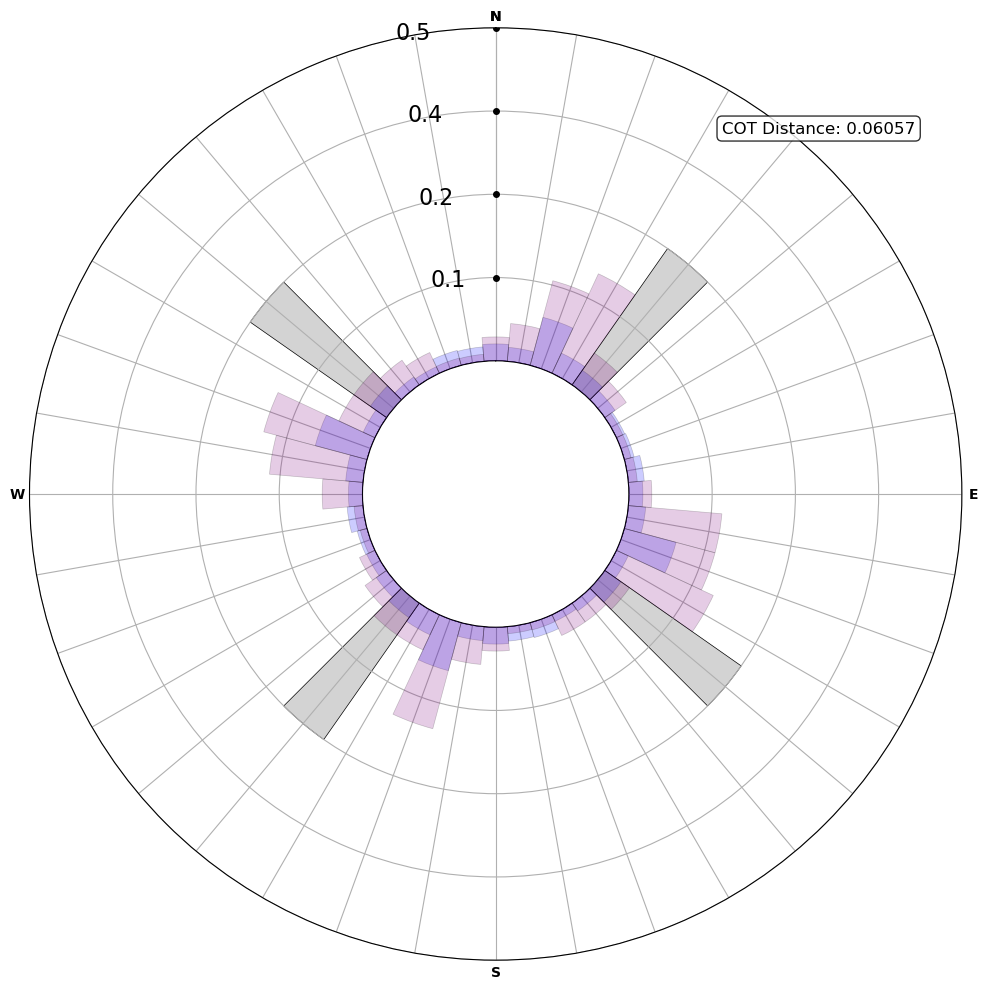

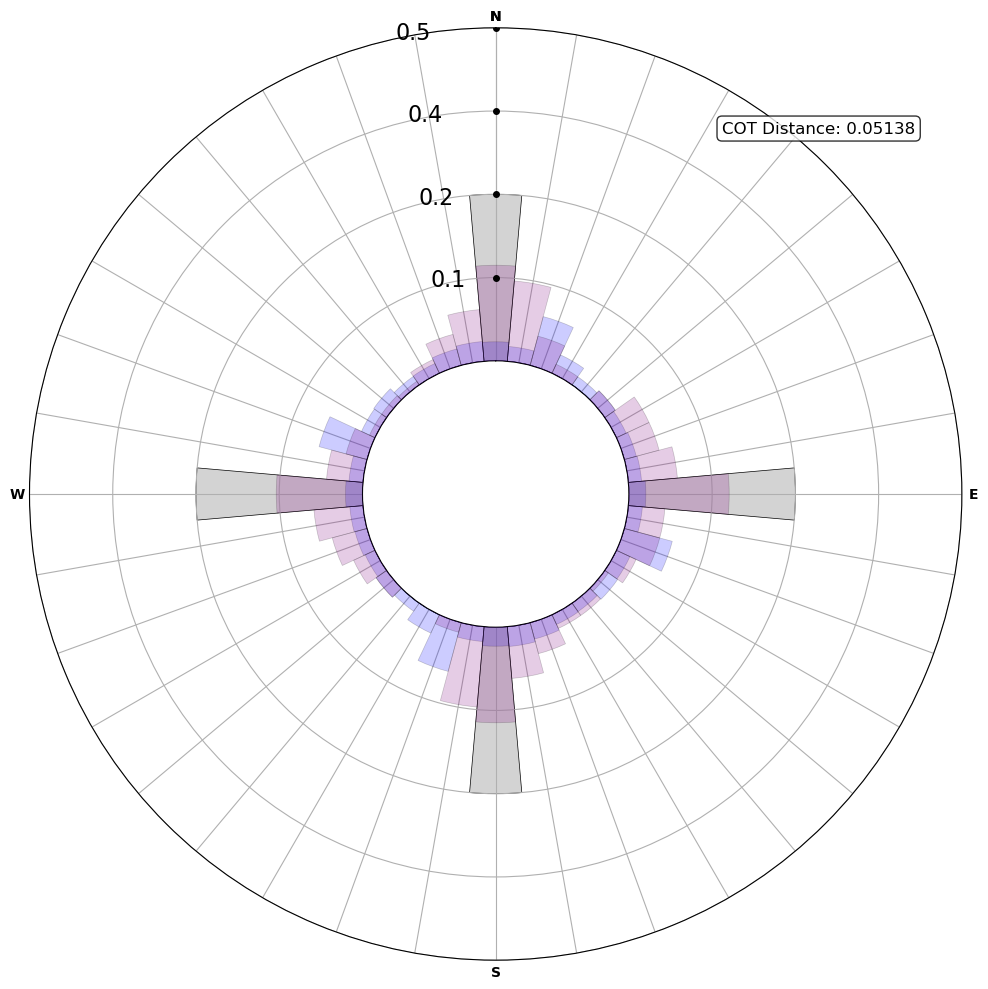

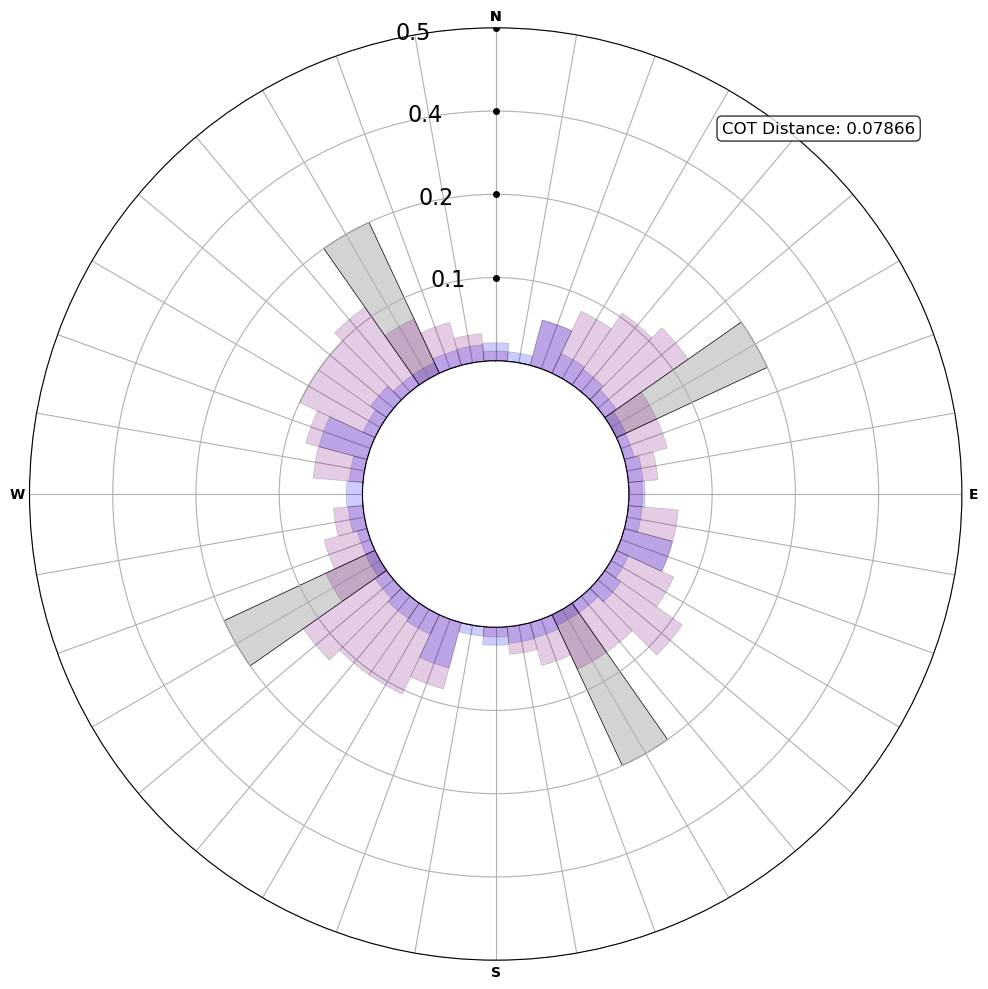

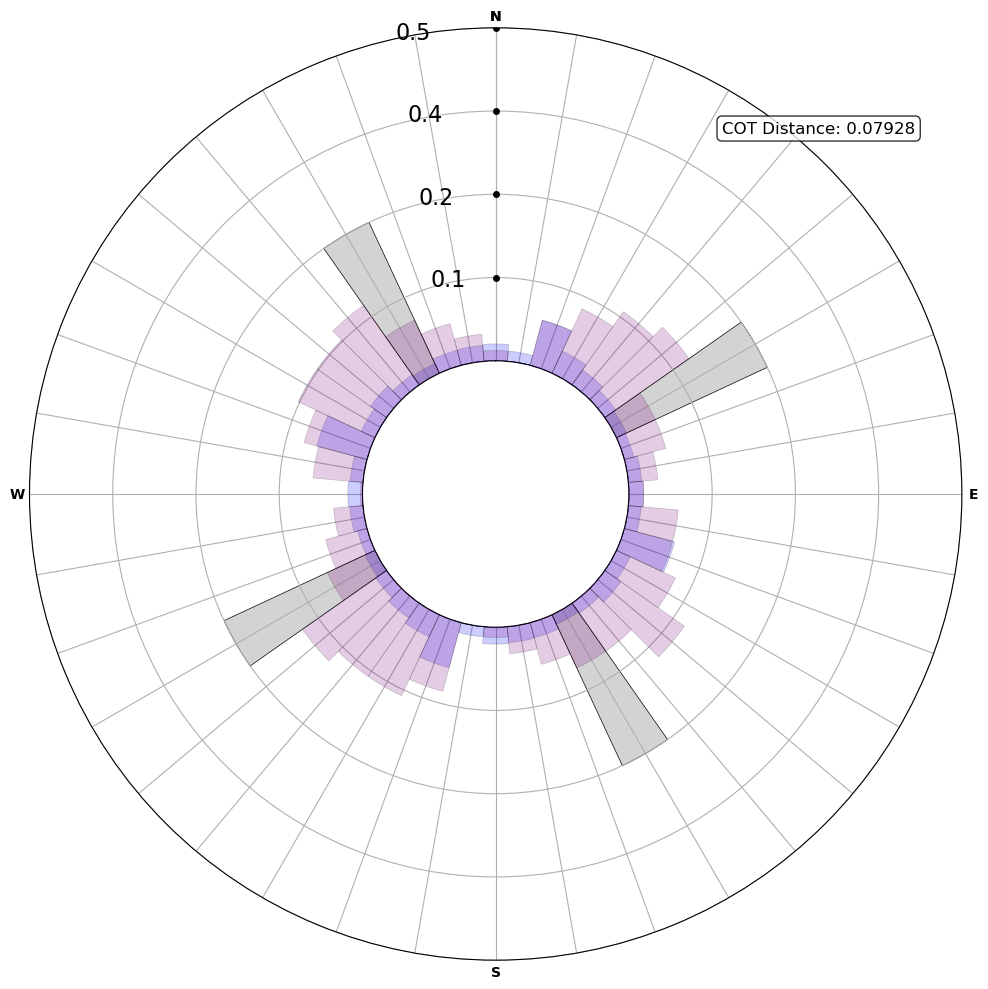

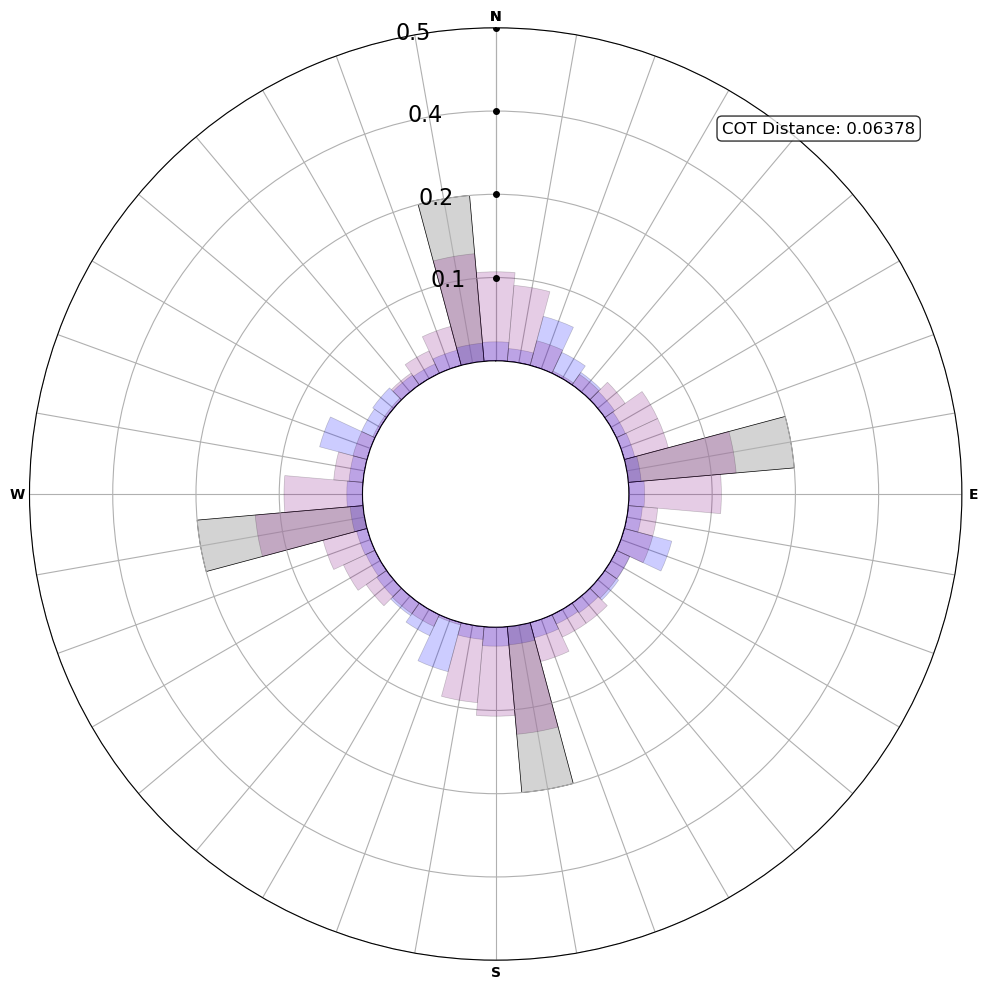

In [1]:
import numpy as np
import pandas as pd
import route_network_analysis as rna
import matplotlib.pyplot as plt

ume_graph = rna.origin_graph.from_graphml("ume_illustration/ume_graph.graphml")
ume_graph.create_od_pairs(min_radius=2950, max_radius=3050, sample_size=5)

ume_od_pairs = ume_graph.od_pairs
for i, od_pair in enumerate(ume_od_pairs):
    od_pair.plot_on_map(f"ume_illustration/od_pair_{i+1}.html", f"ume_illustration/od_pair_{i+1}_graph.png")
    od_pair_env_dist = od_pair.bearing_dist_data["env_undirected_dist"]
    od_pair_route_dist = od_pair.bearing_dist_data["od_undirected_dist_perp"]
    rna.orientation_plotting.plot_COT_distribution_distance(f"ume_illustration/od_pair_{i+1}_orientation.png",od_pair_env_dist, od_pair_route_dist,D=36)




